In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [13]:
df = pd.read_csv("E:\\AIML-Projects\\gamegpt\\data\\steam_clean.csv")

In [14]:
print(df['genres'].unique()[:20])
print(df['genres'].value_counts().head(20))

<StringArray>
[                               'Action',
                   'Action;Free to Play',
          'Action;Free to Play;Strategy',
                      'Action;Adventure',
                                 'Indie',
                        'Indie;Strategy',
                              'Strategy',
                                   'RPG',
 'Animation & Modeling;Video Production',
                            'Action;RPG',
                      'Action;Indie;RPG',
                          'Casual;Indie',
                 'Action;Indie;Strategy',
            'Action;Simulation;Strategy',
                   'Simulation;Strategy',
                     'Action;Simulation',
                                'Racing',
                          'RPG;Strategy',
                      'Adventure;Casual',
                                'Casual']
Length: 20, dtype: str
genres
Action;Indie                     1852
Casual;Indie                     1481
Action;Adventure;Indie           1228
Ad

In [15]:
# Split genres and explode into individual rows
genres_split = df['genres'].str.split(';').explode()
print(genres_split.value_counts().head(15))

genres
Indie                    19410
Action                   11896
Casual                   10204
Adventure                10027
Strategy                  5246
Simulation                5192
RPG                       4307
Early Access              2952
Free to Play              1701
Sports                    1322
Racing                    1024
Violent                    842
Massively Multiplayer      721
Gore                       537
Nudity                     266
Name: count, dtype: int64


In [16]:
# Step 1: Create a dataframe with just name, genres, owners_midpoint
genre_owners = df[['name', 'genres', 'owners_midpoint']].copy()

# Step 2: Split genres into individual rows
genre_owners['genres'] = genre_owners['genres'].str.split(';')
genre_owners = genre_owners.explode('genres')

# Step 3: Group by genre and get total owners
genre_group = genre_owners.groupby('genres')['owners_midpoint'].sum().sort_values(ascending=False).head(15).reset_index()
print(genre_group)

                   genres  owners_midpoint
0                  Action     2.361490e+09
1                   Indie     1.457670e+09
2               Adventure     1.101670e+09
3            Free to Play     1.009785e+09
4                Strategy     7.680400e+08
5                     RPG     6.968250e+08
6                  Casual     5.466800e+08
7              Simulation     5.259050e+08
8   Massively Multiplayer     4.462300e+08
9            Early Access     1.554850e+08
10                 Sports     1.040200e+08
11                 Racing     8.630000e+07
12                Violent     4.089500e+07
13                   Gore     2.578500e+07
14                 Nudity     2.239000e+07


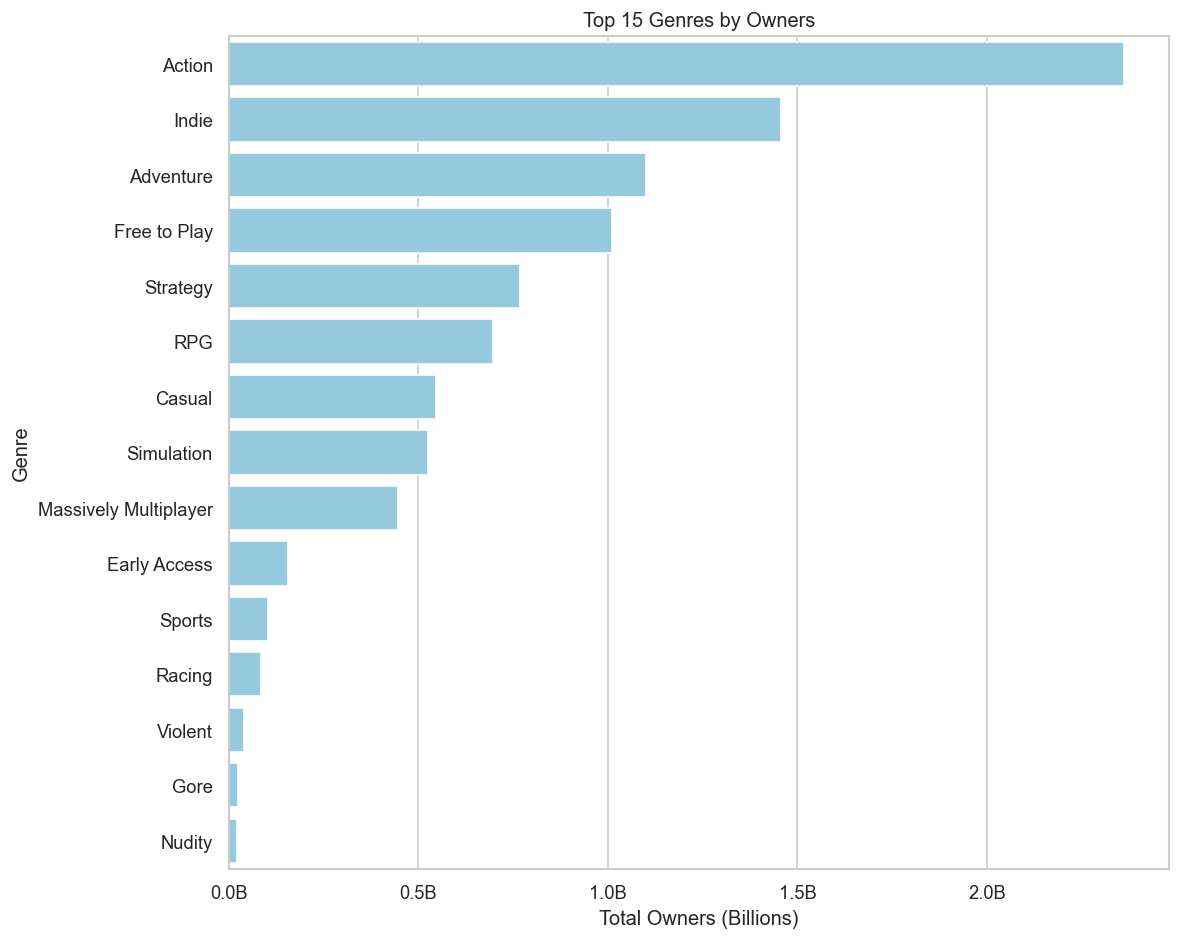

In [17]:
# Step 4: Plot top 15 genres by owners
plt.figure(figsize=(10,8))

sns.barplot(data=genre_group, x='owners_midpoint', y='genres', color='skyblue')

plt.title('Top 15 Genres by Owners')
plt.xlabel('Total Owners (Billions)')
plt.ylabel('Genre')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))

plt.tight_layout()
plt.savefig("..\\reports\\figures\\genre_by_owners.png", dpi=150, bbox_inches='tight')

plt.show()

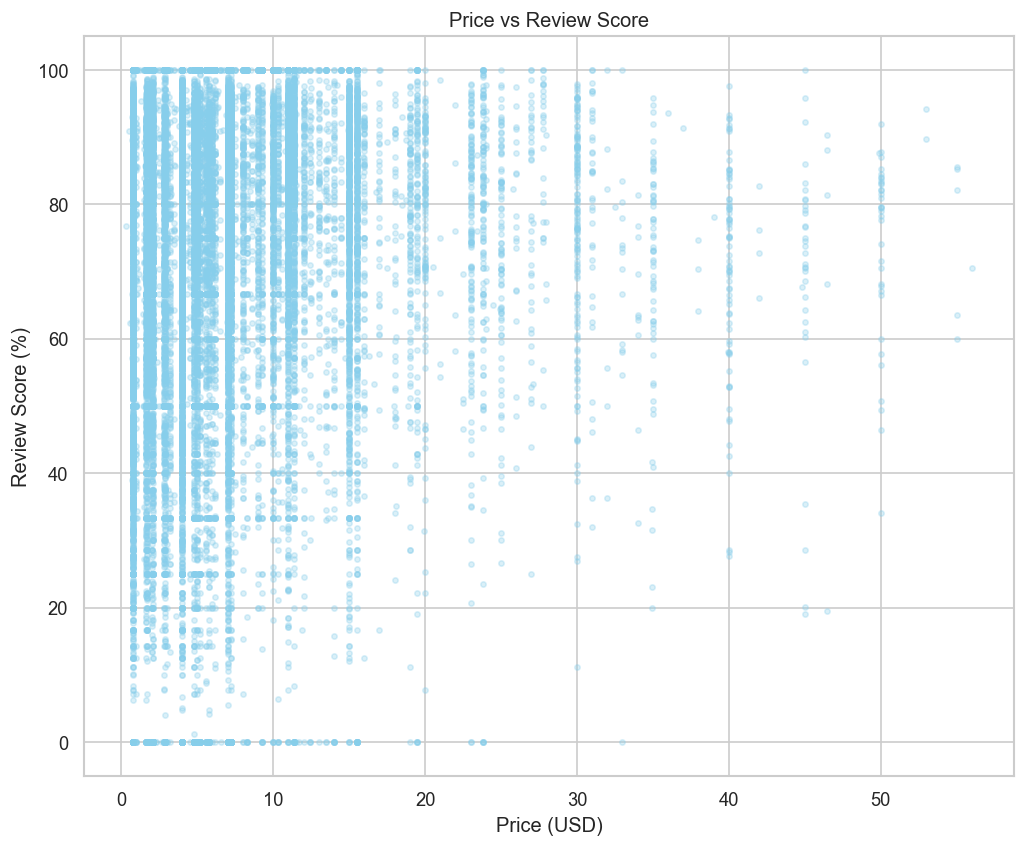

In [18]:
# Filter out free games and extreme prices for cleaner view
df_paid = df[(df['price'] > 0) & (df['price'] < 60)]

# Plot Scatter Plot
plt.figure(figsize=(10,8))

plt.scatter(df_paid['price'], df_paid['review_score'], alpha=0.3, s=10, c='skyblue')

plt.title('Price vs Review Score')
plt.xlabel('Price (USD)')
plt.ylabel('Review Score (%)')

plt.savefig("..\\reports\\figures\\prive_vs_reviews.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
print(df['year'].value_counts().sort_index())

year
1997       1
1998       1
1999       2
2000       2
2001       4
2002       1
2003       3
2004       6
2005       6
2006      48
2007      93
2008     145
2009     305
2010     238
2011     239
2012     320
2013     418
2014    1554
2015    2595
2016    4358
2017    6354
2018    8155
2019    2213
Name: count, dtype: int64


In [20]:
games_per_year = df[(df['year'] >=2000) & (df['year'] <= 2023)]['year'].value_counts().sort_index()
print(games_per_year)

year
2000       2
2001       4
2002       1
2003       3
2004       6
2005       6
2006      48
2007      93
2008     145
2009     305
2010     238
2011     239
2012     320
2013     418
2014    1554
2015    2595
2016    4358
2017    6354
2018    8155
2019    2213
Name: count, dtype: int64


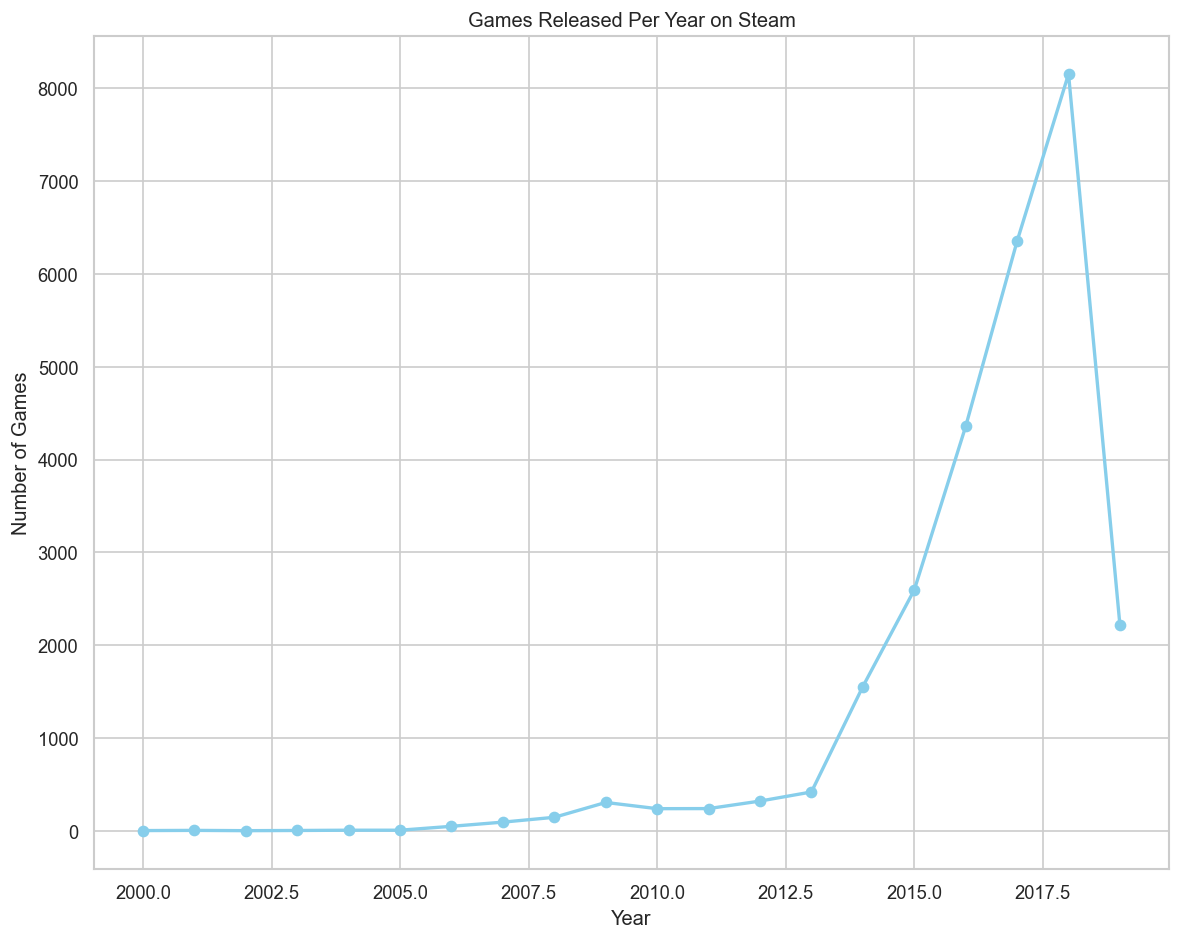

In [21]:
plt.figure(figsize=(10, 8))
plt.plot(games_per_year.index, games_per_year.values, marker='o', color='skyblue', linewidth='2')
plt.title('Games Released Per Year on Steam')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.savefig('..\\reports\\figures\\games_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
genre_playtime = df[['name', 'genres', 'average_playtime']].copy()

genre_playtime['genres'] = genre_playtime['genres'].str.split(';')
genre_playtime = genre_playtime.explode('genres')

# Filter these out
non_games = ['Photo Editing', 'Web Publishing', 'Game Development', 
             'Utilities', 'Design & Illustration', 'Animation & Modeling',
             'Audio Production', 'Software Training', 'Education', 'Nudity', 'Sexual Content', 'Video Production', 'Gore']

genre_playtime_average = genre_playtime[~genre_playtime['genres'].isin(non_games)].groupby('genres')['average_playtime'].mean().sort_values(ascending=False).head(15).reset_index()
print(genre_playtime_average)

                   genres  average_playtime
0   Massively Multiplayer        727.496533
1            Free to Play        555.415050
2                     RPG        277.243093
3                Strategy        193.166984
4              Simulation        154.300077
5               Adventure        151.705695
6                  Action        144.067922
7                  Racing        142.220703
8                  Sports        115.518154
9                   Indie        112.865379
10                 Casual         85.083203
11           Early Access         81.356030
12                Violent         48.200713
13             Accounting          0.000000
14            Documentary          0.000000


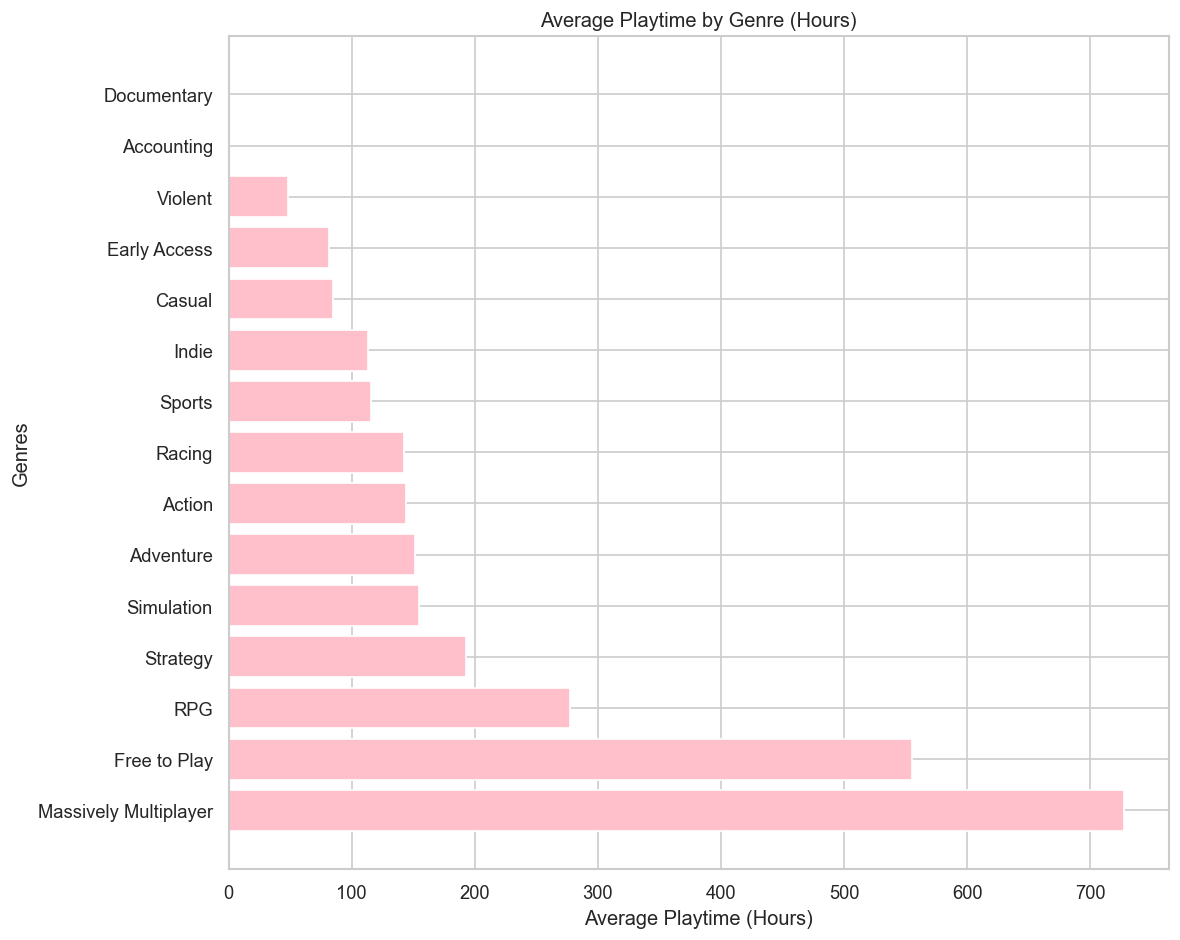

In [36]:
plt.figure(figsize=(10,8))

plt.barh(genre_playtime_average['genres'], genre_playtime_average['average_playtime'], color='pink')
plt.title('Average Playtime by Genre (Hours)')
plt.xlabel('Average Playtime (Hours)')
plt.ylabel('Genres')

plt.tight_layout()

plt.savefig("..\\reports\\figures\\genre_playtime.png", dpi=150, bbox_inches='tight')

plt.show()